In [18]:
import pandas as pd
import os
import shutil
import subprocess
from tqdm import tqdm
import json
from ast import literal_eval
import re
import requests
from Bio import pairwise2
import pickle
import requests
import json
import time
import os
import sys
sys.path.append('../')
from common import  *

# input and output

# 读取所有代谢物的毒性信息

In [19]:
# DILI,Ames,ROA,FDAMDD,SkinSen,Carcinogenicity,EC,EI,Respiratory,H-HT,Neurotoxicity-DI,Ototoxicity,Hematotoxicity,Nephrotoxicity-DI,Genotoxicity,
# 项目名	含义	说明
# DILI	肝毒性	Drug-Induced Liver Injury，药物性肝损伤
# Human Hepatotoxicity	肝毒性	人源肝毒性预测
# Drug-induced Nephrotoxicity	肾毒性	药物诱导的肾损伤
# Drug-induced Neurotoxicity	神经毒性	药物诱导的神经损伤
# Ototoxicity	耳毒性	药物诱导的听力/耳蜗损伤
# Hematotoxicity	血液毒性	对血液系统的毒性（如贫血、白细胞减少）
smiles_DILI_info = {}   #
smiles_H_HT_info = {}   #
smiles_Neurotoxicity_DI_info = {}
smiles_Nephrotoxicity_DI_info = {}
smiles_Hematotoxicity_info = {}

# 项目名	含义	说明
# hERG Blockers	心脏毒性	预测是否阻断 hERG 通道（延长 QT 间期，导致心律失常）
# hERG Blockers (10μM)	心脏毒性（特定浓度）	在 10μM 浓度下的 hERG 阻断预测
# FDAMDD	慢性毒性	FDA最大耐受剂量 (Maximum Recommended Daily Dose) 的预测，间接反映慢性毒性
smiles_hERG_info = {}
smiles_hERG_10um_info = {}
smiles_FDAMDD_info = {}

from pathlib import Path
import pandas as pd

# 初始化路径和结果字典
output_dir = Path('../../Data/Drugbank_SMILES_chunks_admet_results/')

smiles_DILI_info = {}
smiles_H_HT_info = {}
smiles_Neurotoxicity_DI_info = {}
smiles_Nephrotoxicity_DI_info = {}
smiles_Hematotoxicity_info = {}
smiles_hERG_info = {}
smiles_hERG_10um_info = {}
smiles_FDAMDD_info = {}

# 遍历所有 CSV 文件
for csv_file in output_dir.glob('*.csv'):
    df = pd.read_csv(csv_file)

    for _, row in df.iterrows():
        smiles = row['smiles']
        smiles_DILI_info[smiles] = row.get('DILI')
        smiles_H_HT_info[smiles] = row.get('H-HT')
        smiles_Neurotoxicity_DI_info[smiles] = row.get('Neurotoxicity-DI')
        smiles_Nephrotoxicity_DI_info[smiles] = row.get('Nephrotoxicity-DI')
        smiles_Hematotoxicity_info[smiles] = row.get('Hematotoxicity')
        smiles_hERG_info[smiles] = row.get('hERG')
        smiles_hERG_10um_info[smiles] = row.get('hERG-10um')
        smiles_FDAMDD_info[smiles] = row.get('FDAMDD')

In [20]:
def convert_dict_values_to_float_safe(d):
    result = {}
    for k, v in d.items():
        try:
            result[k] = float(v)
        except (ValueError, TypeError):
            # 跳过不能转为 float 的值（如 'Invalid Molecule'）
            continue
    return result

smiles_DILI_info = convert_dict_values_to_float_safe(smiles_DILI_info)
smiles_H_HT_info = convert_dict_values_to_float_safe(smiles_H_HT_info)
smiles_Neurotoxicity_DI_info = convert_dict_values_to_float_safe(smiles_Neurotoxicity_DI_info)
smiles_Nephrotoxicity_DI_info = convert_dict_values_to_float_safe(smiles_Nephrotoxicity_DI_info)
smiles_Hematotoxicity_info = convert_dict_values_to_float_safe(smiles_Hematotoxicity_info)
smiles_hERG_info = convert_dict_values_to_float_safe(smiles_hERG_info)
smiles_hERG_10um_info = convert_dict_values_to_float_safe(smiles_hERG_10um_info)
smiles_FDAMDD_info = convert_dict_values_to_float_safe(smiles_FDAMDD_info)


# 把药物分组，sider按照副作用分组

In [21]:
sider_data_file = '../../Data/Drug/drugbank_oral_smiles.csv'
sider_data = pd.read_csv(sider_data_file)
sider_data

,drug_name,drug_smiles,Toxicity,Bioavailability
0,Gramicidin D,CC(C)C[C@@H](NC(=O)CNC(=O)[C@@H](NC=O)C(C)C)C(...,NaN,0.0
1,Desmopressin,NC(=O)CC[C@@H]1NC(=O)[C@H](CC2=CC=CC=C2)NC(=O)...,Intravenous TDLo in humans is reported to be 0...,0.0
2,Cyclosporine,CC[C@@H]1NC(=O)[C@H]([C@H](O)[C@H](C)C\C=C\C)N...,The oral LD50 in rats is 1480 mg/kg and the TD...,0.0
3,Pyridoxal phosphate,CC1=NC=C(COP(O)(O)=O)C(C=O)=C1O,NaN,1.0
4,Cyanocobalamin,C[C@H](CNC(=O)CC[C@]1(C)[C@@H](CC(N)=O)[C@H]2N...,"LD50 Oral (mouse): > 5,000 mg/kg [F3733]. \r\...",0.0
...,...,...,...,...
2025,Vorasidenib,C[C@@H](NC1=NC(=NC(N[C@H](C)C(F)(F)F)=N1)C1=CC...,There is no information regarding the acute to...,1.0
2026,Pirtobrutinib,COC1=C(C=C(F)C=C1)C(=O)NCC1=CC=C(C=C1)C1=NN([C...,Toxicity information regarding pirtobrutinib i...,1.0
2027,Lomifylline,CN1C2=C(N(CCCCC(C)=O)C=N2)C(=O)N(C)C1=O,NaN,1.0
2028,Revumenib,CCN(C(C)C)C(=O)C1=CC(F)=CC=C1OC1=CN=CN=C1N1CC2...,There are no data regarding overdosage with re...,1.0


In [22]:
import ast

# 读取数据
result_num_df = '../../Result/drugbank_drug_deg_result_filter.csv'
drug_deg_result = pd.read_csv(result_num_df)

# 将字符串解析为列表对象
drug_deg_result['reactant_lst'] = drug_deg_result['reactant_lst'].apply(lambda x: ast.literal_eval(x))
drug_deg_result

,drug_name,reaction_num,reactant_lst,ec4_num,ec4_list,ec3_num,ec3_list
0,Gramicidin D,434,[CC(C)CC(NC(=O)CNC(=O)C(NC=O)C(C)C)C(=O)NC(C)C...,189,"['3.2.1.M17', '3.2.1.116', '3.4.19.5', '6.3.1....",46,"['3.5.1', '3.4.24', '2.3.2', '3.4.21', '3.1.3'..."
1,Desmopressin,187,[N=C(N)NCCCC(NC(=O)C1CCCN1C(=O)C1CSSCCC(=O)NC(...,233,"['3.2.1.M17', '3.2.1.116', '3.4.19.5', '1.3.1....",55,"['3.5.1', '1.6.4', '3.4.24', '2.3.2', '1.3.8',..."
2,Cyclosporine,167,[CC=CC(O)C(C)C(O)C1C(=O)NC(CC)C(=O)N(C)CC(=O)N...,196,"['3.2.1.M17', '3.2.1.116', '3.4.19.5', '1.14.1...",40,"['3.5.1', '3.4.24', '2.3.2', '1.3.99', '3.4.21..."
3,Pyridoxal phosphate,26,"[Cc1ncc(COP(=O)(O)O)c(C(=O)[O-])c1O, Cc1nc(O)c...",98,"['3.2.1.M17', '3.2.1.116', '3.4.19.5', '1.11.2...",28,"['3.5.1', '6.2.1', '3.1.1', '1.5.3', '1.14.13'..."
4,Cyanocobalamin,316,[CC1=C2N=C(C=C3N=C(C(C)=C4C(CCC(N)=O)C(C)(CC(N...,299,"['3.4.19.5', '1.1.1.50', '1.8.99.2', '1.1.3.16...",68,"['3.5.1', '1.8.99', '3.1.8', '6.2.1', '2.3.2',..."
...,...,...,...,...,...,...,...
1910,Vorasidenib,12,[CC(Nc1nc(NC(C)C(F)(F)F)nc(-c2cc(O)c(O)c(Cl)n2...,11,"['1.2.3.1', '3.5.4.43', '3.8.1.8', '3.2.1.78',...",8,"['3.5.4', '1.8.99', '1.14.19', '1.2.3', '1.14...."
1911,Pirtobrutinib,42,[COc1ccc(F)cc1C(=O)NCc1ccc(-c2nn(C(C)C(F)(F)F)...,54,"['3.4.19.5', '6.3.1.2', '3.2.1.35', '5.1.3.8',...",27,"['3.5.1', '1.8.99', '6.2.1', '2.3.2', '3.4.15'..."
1912,Lomifylline,34,"[CC(=O)CCC(O)Cn1cnc2c1c(=O)n(C)c(=O)n2C, C=O, ...",101,"['3.11.1.1', '1.3.1.42', '3.4.19.5', '1.14.13....",32,"['3.5.1', '3.11.1', '1.3.8', '1.3.99', '1.14.1..."
1913,Revumenib,37,[CCN(C(=O)c1cc(F)ccc1Oc1cncnc1N1CC2(CCN(CC3=CC...,71,"['3.4.19.5', '1.14.13.147', '3.2.1.31', '3.2.1...",30,"['3.5.1', '6.2.1', '1.3.99', '1.14.13', '3.4.1..."


In [23]:
sider_data = sider_data[sider_data['drug_name'].isin(drug_deg_result['drug_name'])]
sider_data

,drug_name,drug_smiles,Toxicity,Bioavailability
0,Gramicidin D,CC(C)C[C@@H](NC(=O)CNC(=O)[C@@H](NC=O)C(C)C)C(...,NaN,0.0
1,Desmopressin,NC(=O)CC[C@@H]1NC(=O)[C@H](CC2=CC=CC=C2)NC(=O)...,Intravenous TDLo in humans is reported to be 0...,0.0
2,Cyclosporine,CC[C@@H]1NC(=O)[C@H]([C@H](O)[C@H](C)C\C=C\C)N...,The oral LD50 in rats is 1480 mg/kg and the TD...,0.0
3,Pyridoxal phosphate,CC1=NC=C(COP(O)(O)=O)C(C=O)=C1O,NaN,1.0
4,Cyanocobalamin,C[C@H](CNC(=O)CC[C@]1(C)[C@@H](CC(N)=O)[C@H]2N...,"LD50 Oral (mouse): > 5,000 mg/kg [F3733]. \r\...",0.0
...,...,...,...,...
2025,Vorasidenib,C[C@@H](NC1=NC(=NC(N[C@H](C)C(F)(F)F)=N1)C1=CC...,There is no information regarding the acute to...,1.0
2026,Pirtobrutinib,COC1=C(C=C(F)C=C1)C(=O)NCC1=CC=C(C=C1)C1=NN([C...,Toxicity information regarding pirtobrutinib i...,1.0
2027,Lomifylline,CN1C2=C(N(CCCCC(C)=O)C=N2)C(=O)N(C)C1=O,NaN,1.0
2028,Revumenib,CCN(C(C)C)C(=O)C1=CC(F)=CC=C1OC1=CN=CN=C1N1CC2...,There are no data regarding overdosage with re...,1.0


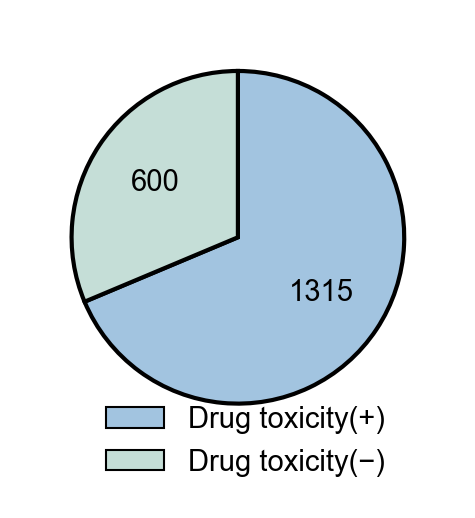

In [24]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 两个值（side effect 正/负）
values = [len(sider_data[~sider_data['Toxicity'].isna()]),
          len(sider_data[sider_data['Toxicity'].isna()])]
labels = ['Drug side effect(+)', 'Drug side effect(−)']
colors = ['#A2C4E0', '#C5DED7']  # 蓝 & 绿灰

# 自定义函数：显示绝对数量
def absolute_value(val):
    total = sum(values)
    count = int(round(val / 100 * total))
    return f'{count}'

# 图设置
plt.figure(figsize=(1.8, 1.8), dpi=300)
plt.rcParams.update({'font.size': 9})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# 画饼图并添加绝对数值
wedges, texts, autotexts = plt.pie(
    values,
    colors=colors,
    startangle=90,
    counterclock=False,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1},
    autopct=absolute_value
)

# 自动文字样式
for autotext in autotexts:
    autotext.set_fontsize(7)
    autotext.set_color('black')

# 图例
legend_elements = [
    Patch(facecolor='#A2C4E0', edgecolor='black', linewidth=0.5, label='Drug toxicity(+)'),
    Patch(facecolor='#C5DED7', edgecolor='black', linewidth=0.5, label='Drug toxicity(−)'),
]
plt.legend(handles=legend_elements,
           loc='center left',
           bbox_to_anchor=(0.12, 0.01),
           fontsize=7,
           frameon=False,
           ncol=1)

plt.savefig('../../Figure/Figure-S11a.pdf', dpi=400, bbox_inches='tight')

plt.show()

In [25]:
from functools import partial
from multiprocessing import Pool, cpu_count
from tqdm import tqdm

# 初始预处理
# result_all_smiles = list(smiles_DILI_info.keys())
# result_all_smiles = [x for x in result_all_smiles if x not in SIDER_smiles_mapping.values()]

def get_mapping_worker(smiles, result_all_smiles, smiles_mapping_set):
    # 如果已经处理过，直接跳过
    if smiles in smiles_mapping_set:
        return (smiles, None)

    for tmp in result_all_smiles:
        if compare_smiles_inchikey(smiles, tmp) == 1:
            # print('success')
            return (smiles, tmp)
    return (smiles, None)

# 只传入key构成的集合用于快速判断
# smiles_mapping_set = set(SIDER_smiles_mapping.keys())

# 使用 partial 绑定函数参数
# worker_with_all = partial(get_mapping_worker,
#                           result_all_smiles=result_all_smiles,
#                           smiles_mapping_set=smiles_mapping_set)

# 获取 SIDER_smiles 列表
# drug_list = sider_data['drug_smiles'].to_list()
# SIDER_smiles = list(set(drug_list))

# 执行并更新 SIDER_smiles_mapping
# with Pool(processes=120) as pool:
#     for result in tqdm(pool.imap(worker_with_all, miss_drug, chunksize=5000), total=len(miss_drug)):
#         smiles, mapped = result
#         if mapped is not None:
#             SIDER_smiles_mapping[smiles] = mapped


# SIDER_smiles_mapping = results
# # 保存为 pickle
# with open('../../Data/Drug/SIDER_smiles_mapping.pkl', 'wb') as f:
#     pickle.dump(SIDER_smiles_mapping, f)

In [26]:
import os
import pandas as pd
import pickle
from multiprocessing import Pool
from functools import partial
from tqdm import tqdm

def fileexist(path):
    return os.path.exists(path)

# 提前加载已有的 smiles 映射（如果有）
mapping_path = '../../Data/Drugbank_smiles_mapping.pkl'
if fileexist(mapping_path):
    with open(mapping_path, 'rb') as f:
        SIDER_smiles_mapping = pickle.load(f)
else:
    # break
    print('no SIDER_smiles_mapping')
    # SIDER_smiles_mapping = {}

    # 目录路径
    admet_folder = '../../Data/Drugbank_SMILES_chunks_admet_results/'
    smiles_folder = '../../Data/Data/Drug/Drugbank_SMILES_chunks/'

    # 请提前定义好这个函数：
    def get_mapping_worker(smiles, result_all_smiles, smiles_mapping_set):
        # 如果已经处理过，直接跳过
        if smiles in smiles_mapping_set:
            return (smiles, None)

        for tmp in result_all_smiles:
            if compare_smiles_inchikey(smiles, tmp) == 1:
                # print('success')
                return (smiles, tmp)
        return (smiles, None)
    
    # 循环处理 num 从 0 到 199
    for num in tqdm(range(0, 1)):
        # ---- 1. 读取 ADMET 预测结果 ----
        admet_file = os.path.join(admet_folder, f'{num}.csv')
        all_files = os.listdir(admet_folder)

        if f'{num}.csv' in all_files:
            tmp_file = pd.read_csv(admet_file)
        else:
            # 查找分段文件（如 0-1.csv, 0-2.csv）
            matching_files = [f for f in all_files if f.startswith(f'{num}-') and f.endswith('.csv')]
            if matching_files:
                tmp_file = pd.DataFrame()
                for fname in matching_files:
                    df_part = pd.read_csv(os.path.join(admet_folder, fname))
                    tmp_file = pd.concat([tmp_file, df_part], ignore_index=True)
            else:
                print(f'❗ No ADMET data found for part {num}, skipping.')
                continue

        if tmp_file.empty or 'smiles' not in tmp_file.columns:
            print(f'❗ Empty or invalid ADMET file at part {num}, skipping.')
            continue

        all_smiles = tmp_file['smiles'].tolist()

        # ---- 2. 读取 SIDER SMILES 文件 ----
        sider_file = os.path.join(smiles_folder, f'Drugbank_drug_degmet_list_part{num}.csv')
        if not os.path.exists(sider_file):
            print(f'❗ SIDER SMILES file not found for part {num}, skipping.')
            continue

        sider_smiles_df = pd.read_csv(sider_file, header=None)
        SIDER_smiles = sider_smiles_df[0].tolist()

        # 👇 在循环中绑定静态副本：已映射 key 的集合（不变）
        smiles_mapping_set = set(SIDER_smiles_mapping.keys())
        
        # ---- 3. 设置映射函数并并行处理 ----
        # 👇 使用 partial 绑定两个参数
        worker_with_all = partial(get_mapping_worker,
                                result_all_smiles=all_smiles,
                                smiles_mapping_set=smiles_mapping_set)

        with Pool(processes=20) as pool:
            for result in tqdm(pool.imap(worker_with_all, SIDER_smiles, chunksize=100),
                            total=len(SIDER_smiles),
                            desc=f'Processing part {num}'):
                if result is not None:
                    smiles, mapped = result
                    if mapped is not None:
                        SIDER_smiles_mapping[smiles] = mapped

    # ---- 4. 保存结果 ----
    with open(mapping_path, 'wb') as f:
        pickle.dump(SIDER_smiles_mapping, f)

    print('✅ All mappings complete and saved.')


In [27]:
len({k:v for k,v in SIDER_smiles_mapping.items() if v!=None})

48722

In [28]:
SIDER_smiles_mapping = {k:v for k,v in SIDER_smiles_mapping.items() if v!=None}

# 处理结果

In [29]:
import ast

# 读取数据
result_num_df = '../../Result/drugbank_drug_deg_result_filter.csv'
drug_deg_result = pd.read_csv(result_num_df)

# 将字符串解析为列表对象
drug_deg_result['reactant_lst'] = drug_deg_result['reactant_lst'].apply(lambda x: ast.literal_eval(x))
drug_deg_result

,drug_name,reaction_num,reactant_lst,ec4_num,ec4_list,ec3_num,ec3_list
0,Gramicidin D,434,[CC(C)CC(NC(=O)CNC(=O)C(NC=O)C(C)C)C(=O)NC(C)C...,189,"['3.2.1.M17', '3.2.1.116', '3.4.19.5', '6.3.1....",46,"['3.5.1', '3.4.24', '2.3.2', '3.4.21', '3.1.3'..."
1,Desmopressin,187,[N=C(N)NCCCC(NC(=O)C1CCCN1C(=O)C1CSSCCC(=O)NC(...,233,"['3.2.1.M17', '3.2.1.116', '3.4.19.5', '1.3.1....",55,"['3.5.1', '1.6.4', '3.4.24', '2.3.2', '1.3.8',..."
2,Cyclosporine,167,[CC=CC(O)C(C)C(O)C1C(=O)NC(CC)C(=O)N(C)CC(=O)N...,196,"['3.2.1.M17', '3.2.1.116', '3.4.19.5', '1.14.1...",40,"['3.5.1', '3.4.24', '2.3.2', '1.3.99', '3.4.21..."
3,Pyridoxal phosphate,26,"[Cc1ncc(COP(=O)(O)O)c(C(=O)[O-])c1O, Cc1nc(O)c...",98,"['3.2.1.M17', '3.2.1.116', '3.4.19.5', '1.11.2...",28,"['3.5.1', '6.2.1', '3.1.1', '1.5.3', '1.14.13'..."
4,Cyanocobalamin,316,[CC1=C2N=C(C=C3N=C(C(C)=C4C(CCC(N)=O)C(C)(CC(N...,299,"['3.4.19.5', '1.1.1.50', '1.8.99.2', '1.1.3.16...",68,"['3.5.1', '1.8.99', '3.1.8', '6.2.1', '2.3.2',..."
...,...,...,...,...,...,...,...
1910,Vorasidenib,12,[CC(Nc1nc(NC(C)C(F)(F)F)nc(-c2cc(O)c(O)c(Cl)n2...,11,"['1.2.3.1', '3.5.4.43', '3.8.1.8', '3.2.1.78',...",8,"['3.5.4', '1.8.99', '1.14.19', '1.2.3', '1.14...."
1911,Pirtobrutinib,42,[COc1ccc(F)cc1C(=O)NCc1ccc(-c2nn(C(C)C(F)(F)F)...,54,"['3.4.19.5', '6.3.1.2', '3.2.1.35', '5.1.3.8',...",27,"['3.5.1', '1.8.99', '6.2.1', '2.3.2', '3.4.15'..."
1912,Lomifylline,34,"[CC(=O)CCC(O)Cn1cnc2c1c(=O)n(C)c(=O)n2C, C=O, ...",101,"['3.11.1.1', '1.3.1.42', '3.4.19.5', '1.14.13....",32,"['3.5.1', '3.11.1', '1.3.8', '1.3.99', '1.14.1..."
1913,Revumenib,37,[CCN(C(=O)c1cc(F)ccc1Oc1cncnc1N1CC2(CCN(CC3=CC...,71,"['3.4.19.5', '1.14.13.147', '3.2.1.31', '3.2.1...",30,"['3.5.1', '6.2.1', '1.3.99', '1.14.13', '3.4.1..."


In [30]:
sider_data

,drug_name,drug_smiles,Toxicity,Bioavailability
0,Gramicidin D,CC(C)C[C@@H](NC(=O)CNC(=O)[C@@H](NC=O)C(C)C)C(...,NaN,0.0
1,Desmopressin,NC(=O)CC[C@@H]1NC(=O)[C@H](CC2=CC=CC=C2)NC(=O)...,Intravenous TDLo in humans is reported to be 0...,0.0
2,Cyclosporine,CC[C@@H]1NC(=O)[C@H]([C@H](O)[C@H](C)C\C=C\C)N...,The oral LD50 in rats is 1480 mg/kg and the TD...,0.0
3,Pyridoxal phosphate,CC1=NC=C(COP(O)(O)=O)C(C=O)=C1O,NaN,1.0
4,Cyanocobalamin,C[C@H](CNC(=O)CC[C@]1(C)[C@@H](CC(N)=O)[C@H]2N...,"LD50 Oral (mouse): > 5,000 mg/kg [F3733]. \r\...",0.0
...,...,...,...,...
2025,Vorasidenib,C[C@@H](NC1=NC(=NC(N[C@H](C)C(F)(F)F)=N1)C1=CC...,There is no information regarding the acute to...,1.0
2026,Pirtobrutinib,COC1=C(C=C(F)C=C1)C(=O)NCC1=CC=C(C=C1)C1=NN([C...,Toxicity information regarding pirtobrutinib i...,1.0
2027,Lomifylline,CN1C2=C(N(CCCCC(C)=O)C=N2)C(=O)N(C)C1=O,NaN,1.0
2028,Revumenib,CCN(C(C)C)C(=O)C1=CC(F)=CC=C1OC1=CN=CN=C1N1CC2...,There are no data regarding overdosage with re...,1.0


In [31]:
for index,row in tqdm(sider_data.iterrows(),total=len(sider_data)):
    if row['drug_smiles'] in SIDER_smiles_mapping:
        pass
    else:
        print(row['drug_smiles'])

  0%|          | 0/1915 [00:00<?, ?it/s]

100%|██████████| 1915/1915 [00:00<00:00, 24581.77it/s]

C[C@H](CNC(=O)CC[C@]1(C)[C@@H](CC(N)=O)[C@H]2N=C1\C(C)=C1/N=C(/C=C3\N=C(\C(\C)=C4\[C@@H](CCC(N)=O)[C@](C)(CC(N)=O)[C@@]2(C)N4[Co+]C#N)[C@@](C)(CC(N)=O)[C@@H]3CCC(N)=O)C(C)(C)[C@@H]1CCC(N)=O)OP([O-])(=O)O[C@@H]1[C@@H](CO)O[C@@H]([C@@H]1O)N1C=NC2=C1C=C(C)C(C)=C2
[N+]1=2[Co-3]345([N+]6=C7[C@H]([C@@](CC(=O)N)(C)[C@@]6([C@@]6(N3C(=C(C)C3=[N+]4C(C(C)(C)[C@@H]3CCC(=O)N)=CC3=[N+]5C(=C7C)[C@@](CC(=O)N)([C@@H]3CCC(=O)N)C)[C@@](C)([C@H]6CC(=O)N)CCC(NC[C@@H](C)OP(=O)(O[C@@H]3[C@H](O[C@H](N(C4=CC(=C(C=C14)C)C)C=2)[C@@H]3O)CO)[O-])=O)[H])C)CCC(=O)N)O[H]
[Ca++].CC([O-])=O.CC([O-])=O
[Ca++].OC[C@@H](O)[C@@H](O)[C@H](O)[C@@H](O)C(O)C([O-])=O.OC[C@@H](O)[C@@H](O)[C@H](O)[C@@H](O)C(O)C([O-])=O
O.O[Al](O)O.O[Al](O)OS(=O)(=O)OC[C@H]1O[C@@](COS(=O)(=O)O[Al](O)O)(O[C@H]2O[C@H](COS(=O)(=O)O[Al](O)O)[C@@H](OS(=O)(=O)O[Al](O)O)[C@H](OS(=O)(=O)O[Al](O)O)[C@H]2OS(=O)(=O)O[Al](O)O)[C@@H](OS(=O)(=O)O[Al](O)O)[C@@H]1OS(=O)(=O)O[Al](O)O
[Br-].[H][C@@]12O[C@]1([H])[C@H]1C[C@H](C[C@@H]2[N+]1(C)C)OC(=O)[C@H](CO)C1=CC=CC

In [32]:
drug_socre_T_1 = []
drug_socre_T_2 = []
drug_socre_T_3 = []
drug_socre_T_4 = []
drug_socre_T_5 = []
drug_socre_T_6 = []
drug_socre_T_7 = []
drug_socre_T_8 = []

drug_socre_F_1 = []
drug_socre_F_2 = []
drug_socre_F_3 = []
drug_socre_F_4 = []
drug_socre_F_5 = []
drug_socre_F_6 = []
drug_socre_F_7 = []
drug_socre_F_8 = []


metabolites_socre_T_1 = []
metabolites_socre_T_2 = []
metabolites_socre_T_3 = []
metabolites_socre_T_4 = []
metabolites_socre_T_5 = []
metabolites_socre_T_6 = []
metabolites_socre_T_7 = []
metabolites_socre_T_8 = []

metabolites_socre_F_1 = []
metabolites_socre_F_2 = []
metabolites_socre_F_3 = []
metabolites_socre_F_4 = []
metabolites_socre_F_5 = []
metabolites_socre_F_6 = []
metabolites_socre_F_7 = []
metabolites_socre_F_8 = []

FC_T_1 = []
FC_T_2 = []
FC_T_3 = []
FC_T_4 = []
FC_T_5 = []
FC_T_6 = []
FC_T_7 = []
FC_T_8 = []

FC_F_1 = []
FC_F_2 = []
FC_F_3 = []
FC_F_4 = []
FC_F_5 = []
FC_F_6 = []
FC_F_7 = []
FC_F_8 = []


for index,row in tqdm(sider_data.iterrows(),total=len(sider_data)):
    if row['drug_smiles'] in SIDER_smiles_mapping:
        drug_name = row['drug_name']
        # drug_smiles = get_smiles_mapping(row['drug_smiles'],all_smiles)
        drug_smiles = SIDER_smiles_mapping[row['drug_smiles']]
        # if pd.isna(row['drug_name']):
        #     continue
        # else:
        #     print(row['drug_name'])
        if len(drug_deg_result[drug_deg_result['drug_name']==drug_name]['reactant_lst'])>0:
            reactant_lst = drug_deg_result[drug_deg_result['drug_name']==drug_name]['reactant_lst'].to_list()[0]
            if drug_smiles in smiles_DILI_info:
                tmp_drug_score1 =  float(smiles_DILI_info[drug_smiles])
                tmp_drug_score2 =  smiles_H_HT_info[drug_smiles]
                tmp_drug_score3 =  smiles_Neurotoxicity_DI_info[drug_smiles]
                tmp_drug_score4 =  smiles_Nephrotoxicity_DI_info[drug_smiles]
                tmp_drug_score5 =  smiles_Hematotoxicity_info[drug_smiles]
                tmp_drug_score6 =  smiles_hERG_info[drug_smiles]
                tmp_drug_score7 =  smiles_hERG_10um_info[drug_smiles]
                tmp_drug_score8 =  smiles_FDAMDD_info[drug_smiles]
                
                tmp_score1 = []
                tmp_score2 = []
                tmp_score3 = []
                tmp_score4 = []
                tmp_score5 = []
                tmp_score6 = []
                tmp_score7 = []
                tmp_score8 = []
                for x in reactant_lst:
                    # x = get_smiles_mapping(x,all_smiles)
                    # print(x)
                    if x in SIDER_smiles_mapping:
                        # print(1)
                        x = SIDER_smiles_mapping[x]
                        if x is not None:
                            if x in smiles_DILI_info and abs(smiles_DILI_info[x] - float(tmp_drug_score1)) > 0.05 and 0.95 > smiles_DILI_info[x] > 0.05:
                                tmp_score1.append(smiles_DILI_info[x])
                            if x in smiles_H_HT_info and abs(smiles_H_HT_info[x] - float(tmp_drug_score2)) > 0.05 and 0.95 > smiles_H_HT_info[x] > 0.05:
                                tmp_score2.append(smiles_H_HT_info[x])
                            if x in smiles_Neurotoxicity_DI_info and abs(smiles_Neurotoxicity_DI_info[x] - float(tmp_drug_score3)) > 0.05 and 0.95 > smiles_Neurotoxicity_DI_info[x] > 0.05:
                                tmp_score3.append(smiles_Neurotoxicity_DI_info[x])
                            if x in smiles_Nephrotoxicity_DI_info and abs(smiles_Nephrotoxicity_DI_info[x] - float(tmp_drug_score4)) > 0.05 and 0.95 > smiles_Nephrotoxicity_DI_info[x] > 0.05:
                                tmp_score4.append(smiles_Nephrotoxicity_DI_info[x])
                            if x in smiles_Hematotoxicity_info and abs(smiles_Hematotoxicity_info[x] - float(tmp_drug_score5)) > 0.05 and 0.95 > smiles_Hematotoxicity_info[x] > 0.05:
                                tmp_score5.append(smiles_Hematotoxicity_info[x])
                            if x in smiles_hERG_info and abs(smiles_hERG_info[x] - float(tmp_drug_score6)) > 0.05 and 0.95 > smiles_hERG_info[x] > 0.05:
                                tmp_score6.append(smiles_hERG_info[x])
                            if x in smiles_hERG_10um_info and abs(smiles_hERG_10um_info[x] - float(tmp_drug_score7)) > 0.05 and 0.95 > smiles_hERG_10um_info[x] > 0.05:
                                tmp_score7.append(smiles_hERG_10um_info[x])
                            if x in smiles_FDAMDD_info and abs(smiles_FDAMDD_info[x] - float(tmp_drug_score8)) > 0.05 and 0.95 > smiles_FDAMDD_info[x] > 0.05:
                                tmp_score8.append(smiles_FDAMDD_info[x])

                    
                    if not pd.isna(row['Toxicity']):
                        drug_socre_T_1.append(tmp_drug_score1)
                        drug_socre_T_2.append(tmp_drug_score2)
                        drug_socre_T_3.append(tmp_drug_score3)
                        drug_socre_T_4.append(tmp_drug_score4)
                        drug_socre_T_5.append(tmp_drug_score5)
                        drug_socre_T_6.append(tmp_drug_score6)
                        drug_socre_T_7.append(tmp_drug_score7)
                        drug_socre_T_8.append(tmp_drug_score8)
                        metabolites_socre_T_1+=tmp_score1
                        metabolites_socre_T_2+=tmp_score2
                        metabolites_socre_T_3+=tmp_score3
                        metabolites_socre_T_4+=tmp_score4
                        metabolites_socre_T_5+=tmp_score5
                        metabolites_socre_T_6+=tmp_score6
                        metabolites_socre_T_7+=tmp_score7
                        metabolites_socre_T_8+=tmp_score8
                        FC_T_1+=[x-tmp_drug_score1 for x in tmp_score1]
                        FC_T_2+=[x-tmp_drug_score2 for x in tmp_score2]
                        FC_T_3+=[x-tmp_drug_score3 for x in tmp_score3]
                        FC_T_4+=[x-tmp_drug_score4 for x in tmp_score4]
                        FC_T_5+=[x-tmp_drug_score5 for x in tmp_score5]
                        FC_T_6+=[x-tmp_drug_score6 for x in tmp_score6]
                        FC_T_7+=[x-tmp_drug_score7 for x in tmp_score7]
                        FC_T_8+=[x-tmp_drug_score8 for x in tmp_score8]
                    else:
                        drug_socre_F_1.append(tmp_drug_score1)
                        drug_socre_F_2.append(tmp_drug_score2)
                        drug_socre_F_3.append(tmp_drug_score3)
                        drug_socre_F_4.append(tmp_drug_score4)
                        drug_socre_F_5.append(tmp_drug_score5)
                        drug_socre_F_6.append(tmp_drug_score6)
                        drug_socre_F_7.append(tmp_drug_score7)
                        drug_socre_F_8.append(tmp_drug_score8)
                        
                        metabolites_socre_F_1+=tmp_score1
                        metabolites_socre_F_2+=tmp_score2
                        metabolites_socre_F_3+=tmp_score3
                        metabolites_socre_F_4+=tmp_score4
                        metabolites_socre_F_5+=tmp_score5
                        metabolites_socre_F_6+=tmp_score6
                        metabolites_socre_F_7+=tmp_score7
                        metabolites_socre_F_8+=tmp_score8
                        
                        FC_F_1+=[x-tmp_drug_score1 for x in tmp_score1]  
                        FC_F_2+=[x-tmp_drug_score2 for x in tmp_score2]  
                        FC_F_3+=[x-tmp_drug_score3 for x in tmp_score3]  
                        FC_F_4+=[x-tmp_drug_score4 for x in tmp_score4]  
                        FC_F_5+=[x-tmp_drug_score5 for x in tmp_score5]  
                        FC_F_6+=[x-tmp_drug_score6 for x in tmp_score6]  
                        FC_F_7+=[x-tmp_drug_score7 for x in tmp_score7]  
                        FC_F_8+=[x-tmp_drug_score8 for x in tmp_score8]  
                        

100%|██████████| 1915/1915 [00:02<00:00, 913.27it/s] 


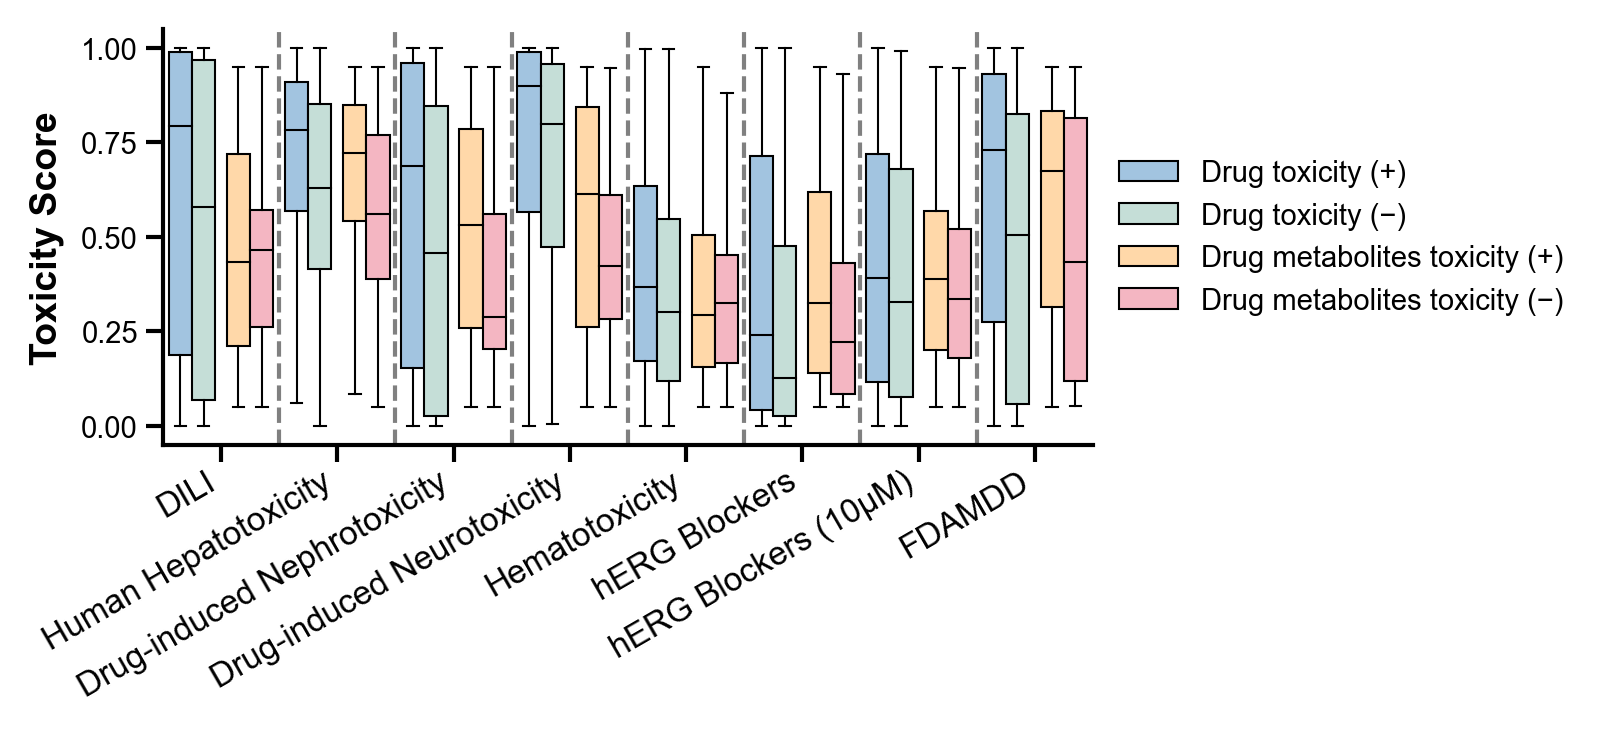

In [33]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# 构建 all_data：8组 × 每组4个子组 = 32 个数据
all_data = []
for i in range(1, 9):
    all_data.append(eval(f"drug_socre_T_{i}"))
    all_data.append(eval(f"drug_socre_F_{i}"))
    all_data.append(eval(f"metabolites_socre_T_{i}"))
    all_data.append(eval(f"metabolites_socre_F_{i}"))

# 位置设置：每组主位置 + 每组4个偏移
group_positions = list(range(1, 9))  # 8组主类
offsets = [-0.35, -0.15, 0.15, 0.35]
positions = []
for pos in group_positions:
    for off in offsets:
        positions.append(pos + off)

# 颜色设置（4种颜色循环使用）
box_colors = ['#A2C4E0', '#C5DED7', '#FFD8A9', '#F4B6C2'] * 8
dot_colors = ['#3C6997', '#6B9080', '#E58E26', '#C94C59'] * 8  # 如启用散点图

# 图设置
plt.figure(figsize=(4, 1.8), dpi=300)
plt.rcParams.update({'font.size': 9})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# 坐标轴样式
plt.xticks([], fontsize=7)
plt.yticks(fontsize=7)
plt.gca().spines['top'].set_linewidth(0)
plt.gca().spines['bottom'].set_linewidth(1)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(0)

# 绘制箱线图
box = plt.boxplot(all_data, positions=positions, widths=0.2,
                  patch_artist=True, showfliers=False)


# 设置箱体样式 + hatch 斜线标记代谢物
for idx, (patch, color) in enumerate(zip(box['boxes'], box_colors)):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.5)


# 设置 whiskers, caps, medians 样式
for part in ['whiskers', 'caps', 'medians']:
    for line in box[part]:
        line.set_color('black')
        line.set_linewidth(0.5)

# # 可选：绘制散点图（建议关闭或少量数据时开启）
# for i, group in enumerate(all_data):
#     x_jittered = positions[i] + np.random.normal(0, 0.06, size=len(group))
#     plt.scatter(x_jittered, group, color=dot_colors[i], edgecolors='none', s=4, zorder=3, alpha=1)

# 坐标轴设置
plt.xlim(0.5, 8.5)
plt.ylim(-0.05, 1.05)
plt.ylabel('Toxicity Score', fontsize=9, fontweight='bold')

# 设置主组刻度和标签
group_labels = ['DILI','Human Hepatotoxicity','Drug-induced Nephrotoxicity','Drug-induced Neurotoxicity','Hematotoxicity','hERG Blockers','hERG Blockers (10μM)','FDAMDD']
plt.xticks(group_positions, group_labels, fontsize=8,rotation=30,ha='right')
# 刻度样式
plt.tick_params(axis='y', direction='out', width=1, which='both', length=4, pad=2)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=4, pad=1)

# 添加组间分隔线（可选）
for i in range(1, 8):
    plt.axvline(x=i + 0.5, color='gray', linestyle='--', linewidth=1)

# 图例元素
legend_elements = [
    Patch(facecolor='#A2C4E0', edgecolor='black', linewidth=0.5,label='Drug toxicity (+)'),
    Patch(facecolor='#C5DED7', edgecolor='black', linewidth=0.5,label='Drug toxicity (−)'),
    Patch(facecolor='#FFD8A9', edgecolor='black', linewidth=0.5,label='Drug metabolites toxicity (+)'),
    Patch(facecolor='#F4B6C2', edgecolor='black', linewidth=0.5,label='Drug metabolites toxicity (−)'),
]
# 添加图例
# plt.legend(handles=legend_elements, loc='upper right', fontsize=7, frameon=False)
plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7, frameon=False)

# 显示图像
plt.savefig('../../Figure/Figure-S11b.pdf', dpi=400, bbox_inches='tight')
plt.show()


In [34]:
from ete3 import NCBITaxa

ncbi = NCBITaxa()

def genus_to_family(genus):
    # 获取 genus taxid
    taxid = ncbi.get_name_translator([genus])[genus][0]
    
    # 获取 lineage
    lineage = ncbi.get_lineage(taxid)
    
    # 获取 rank
    ranks = ncbi.get_rank(lineage)
    
    # 获取名字
    names = ncbi.get_taxid_translator(lineage)
    
    for taxid in lineage:
        if ranks[taxid] == "family":
            return names[taxid]

print(genus_to_family("Bacteroides"))

Bacteroidaceae
